In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [3]:
X,y = load_diabetes(return_X_y=True)

In [4]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [7]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [8]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568969

In [9]:
class SGDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                
                intercept_der = -2 * (y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
                
                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [12]:
sgd = SGDRegressor(learning_rate=0.01,epochs=40)

In [14]:
start = time.time()
sgd.fit(X_train,y_train)
print("The time taken is",time.time() - start)

159.4998065755642 [  54.16267088  -52.82157348  313.62429182  220.56782129   29.59587715
  -11.06861144 -163.84895465  132.82226457  294.05897849  124.5152172 ]
The time taken is 0.5814290046691895


In [15]:
y_pred = sgd.predict(X_test)

In [16]:
r2_score(y_test,y_pred)

0.4141029193674931

In [17]:
from sklearn.linear_model import SGDRegressor

In [18]:
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)

In [19]:
reg.fit(X_train,y_train)

f:\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(learning_rate='constant', max_iter=100)

In [20]:
y_pred = reg.predict(X_test)

In [21]:
r2_score(y_test,y_pred)

0.4324008536167606

# Real world example

In [22]:
from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt
import numpy as np


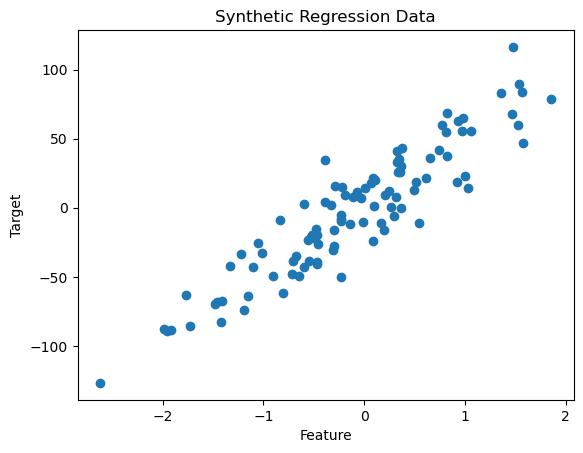

In [23]:
# Create a small regression dataset
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

plt.scatter(X, y)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Synthetic Regression Data')
plt.show()


In [24]:
# Initialize SGD Regressor
sgd_model = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, random_state=42)

# Fit model
sgd_model.fit(X, y)


SGDRegressor(learning_rate='constant', random_state=42)

In [25]:
print("Slope (m):", sgd_model.coef_[0])
print("Intercept (b):", sgd_model.intercept_[0])


Slope (m): 47.40259380213593
Intercept (b): 1.9807676217461327


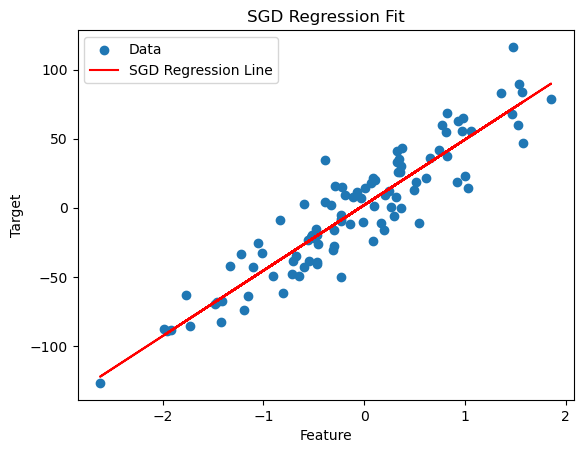

In [26]:
y_pred = sgd_model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='SGD Regression Line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('SGD Regression Fit')
plt.legend()
plt.show()
